In [72]:
import random
import numpy as np
import torch

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


In [73]:
random.uniform(-1, 1)

0.2788535969157675

out = X * W + b

In [74]:
n = 1 # number of neurons
num_inputs = 3

X = [255, 0, 128]

W = [random.uniform(-1, 1) for _ in range(num_inputs)]

b = [random.uniform(-1, 1) for _ in range(n)]


In [75]:
X, W, b

([255, 0, 128],
 [-0.9499784895546661, -0.4499413632617615, -0.5535785237023545],
 [0.4729424283280248])

In [76]:
X_mul_W = []
X_mul_W = [X[i] * W[i] for i in range(num_inputs)]

out = sum(X_mul_W) + b[0]
out

-312.6296234420132

## Class

In [77]:
import math

class Neuron():
    def __init__(self, num_inputs):
        self.num_inputs = num_inputs
        self.W = [random.uniform(-1, 1) for _ in range(num_inputs)]
        self.b = random.uniform(-1, 1)
    
    def __call__(self, X):
        X_mul_W = [X[i] * self.W[i] for i in range(self.num_inputs)]
        out = sum(X_mul_W) + self.b
        out = math.tanh(out)
        return out
    
n1 = Neuron(2)
X = [2.0,  3.0]
n1(X)

0.9773086030141074

In [78]:
import math

class Neuron():
    def __init__(self, num_inputs):
        self.num_inputs = num_inputs
        self.W = [random.uniform(-1, 1) for _ in range(num_inputs)]
        self.b = random.uniform(-1, 1)
    
    def __call__(self, X):
        X_mul_W = [X[i] * self.W[i] for i in range(self.num_inputs)]
        out = sum(X_mul_W) + self.b
        out = math.tanh(out)
        return out
    
class Layer():
    def __init__(self, num_inputs, num_neurons):
        self.neurons = [Neuron(num_inputs) for _ in range(num_neurons)]

    def __call__(self, X):
        outs = [neuron(X) for neuron in self.neurons]
        return outs

n1 = Layer(2, 3)
X = [2.0,  3.0]
n1(X)

[-0.9987690578042914, -0.9978692776062354, 0.3004988477986029]

In [79]:
import math
import torch

class Neuron():
    def __init__(self, num_inputs):
        self.num_inputs = num_inputs
        # self.W = [random.uniform(-1, 1) for _ in range(num_inputs)]
        # self.b = random.uniform(-1, 1)
    
        self.W = [torch.tensor(random.uniform(-1, 1), requires_grad=True) for _ in range(num_inputs)]
        self.b = torch.tensor(random.uniform(-1, 1), requires_grad=True)
    
    def __call__(self, X):
        X_mul_W = [X[i] * self.W[i] for i in range(self.num_inputs)]
        out = sum(X_mul_W) + self.b
        out = torch.relu(out)
        return out
    
    def parameters(self):
        return (self.W + [self.b])
    
class Layer():
    def __init__(self, num_inputs, num_neurons):
        self.neurons = [Neuron(num_inputs) for _ in range(num_neurons)]

    def __call__(self, X):
        outs = [neuron(X) for neuron in self.neurons]
        return outs[0] if len(self.neurons) == 1 else outs
    
    def parameters(self):
        return [neuron.parameters() for neuron in self.neurons]
    
class MLP():
    def __init__(self, num_inputs, layers_shape):
        layers_shape = [num_inputs] + layers_shape # [3, 4, 4, 1]
        self.layers = [Layer(layers_shape[i], layers_shape[i+1]) for i in range(len(layers_shape)-1)]

    def __call__(self, X):
        out = X
        for layer in self.layers:
            out = layer(out)
        return out
    
    def parameters(self):
        params = []
        for layer in self.layers:
            for neuron in layer.neurons:
                params.extend(neuron.parameters())
        return params
        # return [params.extend(neuron.parameters() for neuron in layer.neurons for layer in self.layers)]
    
# X = [2.0, -4.0, -10.0]
# mlp = MLP(3, [4, 4, 1])
# outs = mlp(X)


# print(outs)

### EvapoTranspiration Prediction

In [80]:
import numpy as np
import pandas as pd
import math

def generate_et_dataset(n=1_000_000, seed=42):
    """
    Generate a synthetic dataset of weather features with ET as the target.
    
    Features:
        avgtemp_c, maxtemp_c, mintemp_c, avgwind_kph, avghumidity, sunHour
    Target:
        et (mm/day) — computed via Penman-Monteith
    """
    rng = np.random.default_rng(seed)

    # --- Generate realistic weather features ---
    avgtemp_c   = rng.uniform(-5, 45, n)                          # °C
    temp_spread = rng.uniform(2, 12, n)                            # max-min range
    mintemp_c   = avgtemp_c - temp_spread * rng.uniform(0.3, 0.6, n)
    maxtemp_c   = avgtemp_c + temp_spread * rng.uniform(0.4, 0.7, n)
    avgwind_kph = rng.uniform(2, 50, n)                            # km/h
    avghumidity = rng.uniform(10, 100, n)                          # %
    sunHour     = rng.uniform(0.5, 14, n)                          # hours

    # --- Vectorised ET calculation (mirrors the notebook functions) ---
    # 1) Solar radiation  (calculate_solar_radiation logic)
    tmax_k = maxtemp_c + 273.15
    tmin_k = mintemp_c + 273.15
    albedo = 0.23
    altitude = 0
    ea_const = 2.5
    sigma = 4.903e-9

    total_solar = sunHour * 0.2 * 4.92
    rso = (0.75 + 2e-5 * altitude) * total_solar
    # Avoid division by zero where rso might be tiny
    ratio = np.clip(total_solar / np.where(rso == 0, 1e-9, rso), 0, 1.5)
    rl = (sigma * ((tmax_k**4 + tmin_k**4) / 2)
          * (0.34 - 0.14 * np.sqrt(ea_const))
          * (1.35 * ratio - 0.35))
    solar_radiation = (1 - albedo) * total_solar - rl

    # 2) Penman-Monteith ET  (calculate_et logic)
    temp = avgtemp_c
    humidity = avghumidity
    wind_speed_ms = avgwind_kph / 3.6          # convert km/h → m/s

    L = 2.45
    cp = 1.013e-3
    epsilon = 0.622
    pressure = 101.3 * ((293 - 0.0065 * altitude) / 293) ** 5.26

    es = 0.6108 * np.exp((17.27 * temp) / (temp + 237.3))
    ea = es * (humidity / 100)
    delta = (4098 * es) / ((temp + 237.3) ** 2)
    gamma = (cp * pressure) / (epsilon * L)

    Rn = solar_radiation * 0.77
    u2 = wind_speed_ms * (4.87 / np.log(67.8 * 2 - 5.42))

    et = ((0.408 * delta * Rn + gamma * (900 / (temp + 273)) * u2 * (es - ea))
          / (delta + gamma * (1 + 0.34 * u2)))
    et = np.round(et, 2)

    # --- Build DataFrame ---
    dataset = pd.DataFrame({
        'avgtemp_c':   np.round(avgtemp_c, 2),
        'maxtemp_c':   np.round(maxtemp_c, 2),
        'mintemp_c':   np.round(mintemp_c, 2),
        'avgwind_kph': np.round(avgwind_kph, 2),
        'avghumidity': np.round(avghumidity, 2),
        'sunHour':     np.round(sunHour, 2),
        'et':          et
    })

    return dataset

dataset = generate_et_dataset()
print(f"Shape: {dataset.shape}")
dataset.head(10)

Shape: (1000000, 7)


,avgtemp_c,maxtemp_c,mintemp_c,avgwind_kph,avghumidity,sunHour,et
0,33.70,38.37,28.77,29.03,87.73,13.17,2.30
1,16.94,19.76,13.03,12.21,77.56,2.21,0.54
2,37.93,38.95,36.89,48.67,78.71,3.87,4.29
3,29.87,33.21,27.05,36.77,52.37,9.54,7.56
4,-0.29,4.44,-3.02,12.47,10.31,6.50,2.18
5,43.78,46.78,42.17,2.90,20.50,10.90,1.91
6,33.06,39.04,29.46,32.87,33.08,12.87,11.27
7,34.30,39.90,30.23,42.62,80.63,6.91,3.48
8,1.41,8.93,-2.42,20.06,40.39,2.31,1.84
9,17.52,20.35,15.68,7.50,75.50,8.24,0.91


### Train 

In [96]:
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split

X = dataset.drop(columns=['et'])
y = dataset['et']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [97]:
batch_size = 1
# Normalize features (zero mean, unit variance)
# X_mean = X_train.mean()
# X_std  = X_train.std()
# X_train = (X_train - X_mean) / X_std
# X_test  = (X_test  - X_mean) / X_std

def get_batch(split):
    if split == 'train':
        X_data, y_data = X_train, y_train
    else:
        X_data, y_data = X_test, y_test

    # rands1 = [int(random.uniform(0, len(X_data))) for _ in range(batch_size)]
    rands = torch.randint(high=len(X_data), size=(batch_size,))
    idx = rands.tolist()

    # X = [X_data.iloc[rand].values for rand in rands1]
    # y = [y_data.iloc[rand] for rand in rands1]
    # print(X, y)
    X = torch.tensor(X_data.iloc[idx].values, dtype=torch.float32)
    y = torch.tensor(y_data.iloc[idx].values, dtype=torch.float32).unsqueeze(1)
    # print("two is ", X, y)
    return X, y



add parameters to classes

In [ ]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

max_iters = 100
mlp = MLP(6, [16, 16, 1])
for i in range(max_iters):
    lr = 0.01 if i < 500 else (0.005 if i < 1000 else 0.001)
    # predictions
    xb, yb = get_batch('train')
    predictions = [mlp(xb[j]) for j in range(len(xb))]
    # loss
    loss =  sum([(yb[j].item() - predictions[j])**2 for j in range(len(predictions))]) / len(predictions)
    if i % 100 == 0:
        print(f"iter {i}, loss = {loss.item():.4f}, lr = {lr}")
    
    # backpropagation
    for p in mlp.parameters():
            if p.grad is not None:
                p.grad.zero_() # they add up always, so zeroing the gradients
    loss.backward()
    # Gradient Descent
    with torch.no_grad(): # saying to PyTorch to not track these operations in the computation graph (so PyTorch doesn't waste memory tracking gradients for the update step).
        for p in mlp.parameters():
            p -= lr * p.grad
            

print("Loss after training is = ", loss.item())    

iter 0, loss = 566.3707, lr = 0.01
Loss after training is =  0.9604000449180603


### Compare

MAE:  1.1915
MSE:  1.4197
RMSE: 1.1915


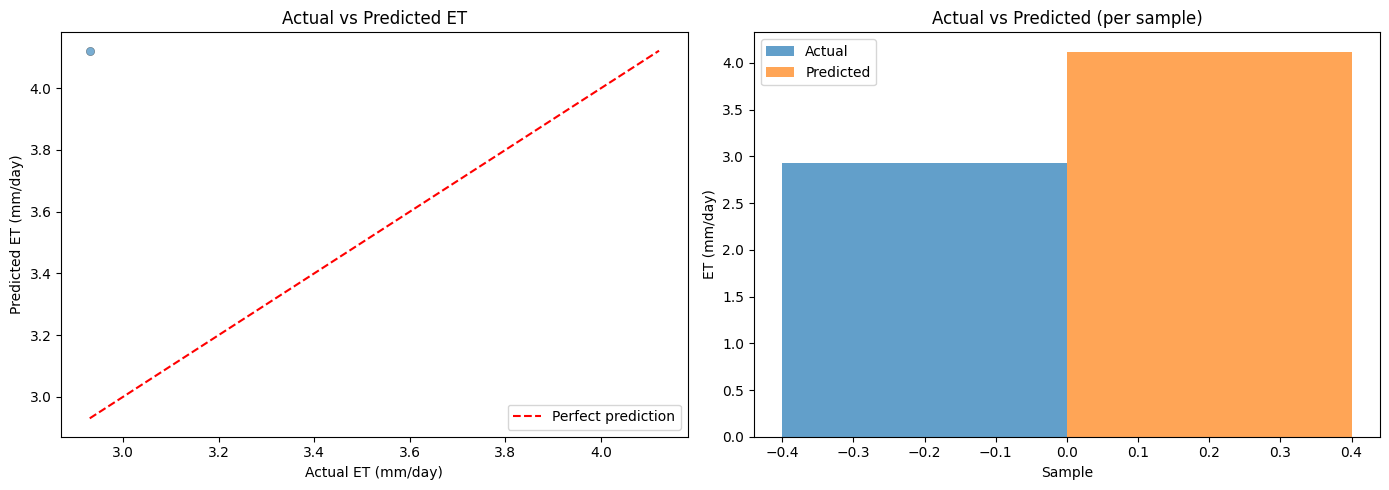

In [84]:
import matplotlib.pyplot as plt
import numpy as np

def compare_predictions(model, split='test'):
    """
    Compare actual ET values vs model predictions for the custom MLP.
    """
    xb, yb = get_batch(split)

    # Get predictions one sample at a time (custom MLP doesn't do batch forward)
    with torch.no_grad():
        preds = [model(xb[j]).item() for j in range(len(xb))]

    actual = np.array([yb[j].item() for j in range(len(yb))])
    predicted = np.array(preds)

    # Metrics
    mae = np.mean(np.abs(actual - predicted))
    mse = np.mean((actual - predicted) ** 2)
    rmse = np.sqrt(mse)

    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")

    # Plot: Actual vs Predicted scatter
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(actual, predicted, alpha=0.6, edgecolors='k', linewidths=0.3)
    min_val = min(actual.min(), predicted.min())
    max_val = max(actual.max(), predicted.max())
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
    axes[0].set_xlabel('Actual ET (mm/day)')
    axes[0].set_ylabel('Predicted ET (mm/day)')
    axes[0].set_title('Actual vs Predicted ET')
    axes[0].legend()

    # Plot: Side-by-side bar comparison
    indices = np.arange(len(actual))
    axes[1].bar(indices - 0.2, actual, width=0.4, label='Actual', alpha=0.7)
    axes[1].bar(indices + 0.2, predicted, width=0.4, label='Predicted', alpha=0.7)
    axes[1].set_xlabel('Sample')
    axes[1].set_ylabel('ET (mm/day)')
    axes[1].set_title('Actual vs Predicted (per sample)')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

compare_predictions(mlp)

### Using PyTorch

In [99]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# PyTorch implementation of the same MLP training
import torch
import torch.nn as nn
import torch.optim as optim


model = nn.Sequential(
            nn.Linear(len(X_train.columns), 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

# Convert data to torch tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# Training loop
for i in range(200):
    model.train() # saying to PyTorch that the model in training process
    # predictions
    preds = model(X_train_tensor)
    # loss
    loss = loss_fn(preds, y_train_tensor)
    # backpropagation
    optimizer.zero_grad() # zeroing the gradients
    loss.backward()
    # Gradient Descent
    optimizer.step()

    if i % 50 == 0:
        print(f"Iteration {i}, Loss: {loss.item():.4f}")

# Evaluation
model.eval() # saying to PyTorch that the model in evaluation process
with torch.no_grad():
    test_preds = model(X_test_tensor)
    test_loss = loss_fn(test_preds, y_test_tensor)
    print(f"Test Loss: {test_loss.item():.4f}")


Iteration 0, Loss: 34.1843
Iteration 50, Loss: 2.2710
Iteration 100, Loss: 1.4068
Iteration 150, Loss: 1.2623
Test Loss: 1.1742
